# **PONTIFICIA UNIVERSIDAD JAVERIANA**
## **Procesamiento de alto volumen de datos**
**Fecha:** 7 de Abril del 2026

**Autor:** Grupo Sigma

**Tema:** Proyecto de Big Data

**Objetivo:** 
- Entender la importancia del uso de herramientas de Big Data en entornos empresariales, a fin de poder solucionar preguntas de negocio.
- Entender el paso a paso de un proyecto de procesamiento de datos para la generación de hallazgos de valor basado en la metodología CRISP-DM.
- Documentar la implementación de un cluster como infraestructura de procesamiento de grandes volúmenes de datos, a través de máquinas virtuales
- Realizar procesamiento de datos aplicado a entender y mejorar los indicadores ICFES en el territorio nacional.
- Integrar conjuntos de datos territoriales, sociales y económicos con los resultados educativos nacionales.
- Realizar exploración y transformación del conjunto global de datos disponible que permita su análisis de forma correcta y sin sesgos.


**Version:** Entrega 1

### Para asegurar que el proyecto funcione correctamente con pandas, matplotlib, seaborn y findspark, ejecutar el siguiente comando desde la raíz del proyecto
```bash
pip install -r requirements.txt
```

In [1]:
### Importación de bibliotecas basicas 
import os                       # -> Para gestion de archivos y procesos
import sys                      # -> Para manejo de recursos del sistema
import pandas as pd             # -> Para graficar y objetos dataframe
import numpy as np              # -> Para algebra matricial
import matplotlib.pyplot as plt # -> Para formatos de graficas
import seaborn as sns           # -> Para estadistica y graficar
import scipy.stats as stats     # -> Para pruebas estadisticas
from functools import reduce    # -> Para aplicar reducción de datos (calcular metricas)
import matplotlib.ticker as mticker # -> Para manejo y personalización de graficos

In [2]:
### Importacion de bibliotecas especializadas
import findspark                                # -> Para manejo del entorno de PySpark
findspark.init('/Almacen/Spark')                # -> Se inicia el entorno para PySpark
from pyspark import SparkConf, SparkContext     # -> Para contexto y configuración de PySpark
from pyspark.sql import SparkSession            # -> Para manejo de Sesion en entorno de consultas SQL
from pyspark.sql import functions as F          # -> Para funciones de manipulacion de columnas
from pyspark.sql.types import IntegerType, StringType, DoubleType # -> Para definir tipos de datos
from pyspark.ml.feature import VectorAssembler  # -> Para construcción de vectores  
from pyspark.ml.stat import Correlation         # -> Para calculo de correlaciones
from pyspark.sql.window import Window           # -> Para calculos acumulados

In [3]:
configura = SparkConf()
configura.set('spark.scheduler.mode', 'FAIR')
configura.set('spark.scheduler.allocation','/Almacen/Spark/conf/fairscheduler.xml')
configura.setMaster('spark://10.43.97.166:7077')
configura.setAppName('SigmaSPARK')

sparkSigma = SparkSession.builder.config(conf=configura).getOrCreate()
sparkSigma

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/08 20:40:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Actividades a realizar

- Lectura de data
- Descripción de los datos
- Exploración de los datos
- Reporte de calidad
- Planteamiento de preguntas investigativas
- Limpieza, filtro y transformaciones iniciales

## **Lectura de data**

In [4]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El acceso se hara desde la carpeta data del proyecto, donde se encuentran las bases de datos seleccionadas
dfPy00 = sparkSigma.read.format("csv").option("header","true").load("../data/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR,_BÁSICA_Y_MEDIA_POR_MUNICIPIO_20260407.csv")
dfPy00.show(5)

26/04/08 20:41:17 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----+----------------+-------------+-------------------+------------+----------+---------------+--------------+-----------------------+--------------+-------------------------+-----------------------+-------------------------+--------------------+---------------+--------------------------+------------------------+--------------------------+---------------------+------------------------+---------------------------+---------+--------------------+------------------+--------------------+---------------+----------+---------------------+-------------------+---------------------+----------------+-----------+----------------------+--------------------+----------------------+-----------------+----------+---------------------+-------------------+---------------------+----------------+
| AÑO|CÓDIGO_MUNICIPIO|    MUNICIPIO|CÓDIGO_DEPARTAMENTO|DEPARTAMENTO|CÓDIGO_ETC|            ETC|POBLACIÓN_5_16|TASA_MATRICULACIÓN_5_16|COBERTURA_NETA|COBERTURA_NETA_TRANSICIÓN|COBERTURA_NETA_PRIMARIA|COBERTURA_NE

## **Descripción de los datos**

In [5]:
dfPy00.printSchema()

root
 |-- AÑO: string (nullable = true)
 |-- CÓDIGO_MUNICIPIO: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- CÓDIGO_DEPARTAMENTO: string (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- CÓDIGO_ETC: string (nullable = true)
 |-- ETC: string (nullable = true)
 |-- POBLACIÓN_5_16: string (nullable = true)
 |-- TASA_MATRICULACIÓN_5_16: string (nullable = true)
 |-- COBERTURA_NETA: string (nullable = true)
 |-- COBERTURA_NETA_TRANSICIÓN: string (nullable = true)
 |-- COBERTURA_NETA_PRIMARIA: string (nullable = true)
 |-- COBERTURA_NETA_SECUNDARIA: string (nullable = true)
 |-- COBERTURA_NETA_MEDIA: string (nullable = true)
 |-- COBERTURA_BRUTA: string (nullable = true)
 |-- COBERTURA_BRUTA_TRANSICIÓN: string (nullable = true)
 |-- COBERTURA_BRUTA_PRIMARIA: string (nullable = true)
 |-- COBERTURA_BRUTA_SECUNDARIA: string (nullable = true)
 |-- COBERTURA_BRUTA_MEDIA: string (nullable = true)
 |-- TAMAÑO_PROMEDIO_DE_GRUPO: string (nullable = true)
 |-

Este conjunto de datos recopila indicadores educativos del sector oficial colombiano desagregados por Entidad Territorial Certificada (ETC) y municipio. Su propósito es centralizar métricas de cobertura, matrícula, deserción, aprobación, reprobación y repitencia escolar por nivel educativo (transición, primaria, secundaria y media), permitiendo análisis comparativos territoriales y temporales del desempeño del sistema educativo público. En el contexto del proyecto, permite explorar la relación entre las condiciones educativas de cada municipio y el rendimiento de los estudiantes en las pruebas Saber 11 del ICFES.

## Diccionario de datos

| Nombre de la Variable | Tipo de Dato | Definición | Ejemplo |
| :--- | :--- | :--- | :--- |
| `AÑO` | **Número** | Año de vigencia del indicador reportado. | `2024` |
| `CÓDIGO_MUNICIPIO` | **String** | Código numérico único del DANE para identificar el municipio. Se maneja como texto para conservar ceros iniciales. | `"05004"` |
| `MUNICIPIO` | **String** | Nombre del municipio al que corresponden los indicadores. | `"Abriaquí"` |
| `CÓDIGO_DEPARTAMENTO` | **String** | Código numérico del DANE para identificar el departamento. Se maneja como texto para conservar ceros iniciales. | `"05"` |
| `DEPARTAMENTO` | **String** | Nombre del departamento al que pertenece el municipio. | `"Antioquia"` |
| `CÓDIGO_ETC` | **Número** | Código de la Entidad Territorial Certificada (ETC) o Secretaría de Educación Certificada. | `3758` |
| `ETC` | **String** | Nombre de la Entidad Territorial Certificada o Secretaría de Educación Certificada responsable del reporte. | `"Antioquia (ETC)"` |
| `POBLACIÓN_5_16` | **String** | Población en edad teórica de estudiar (5 a 16 años) según proyecciones del DANE. Se maneja como texto dado que en la fuente original está definida así. | `"499"` |
| `TASA_MATRICULACIÓN_5_16` | **Número** | Proporción de la población entre 5 y 16 años que se encuentra asistiendo al sistema educativo. Puede superar el 100% por flujos migratorios no capturados en las proyecciones del DANE. | `56.11%` |
| `COBERTURA_NETA` | **Número** | Relación entre estudiantes matriculados en transición, primaria, secundaria y media con edad teórica (5–16 años) y la población total de esa misma edad. Puede superar el 100% por flujos migratorios. | `56.11%` |
| `COBERTURA_NETA_TRANSICIÓN` | **Número** | Relación entre estudiantes matriculados en transición con edad teórica (5 años) y la población total de esa edad. Puede superar el 100% por flujos migratorios. | `39.53%` |
| `COBERTURA_NETA_PRIMARIA` | **Número** | Relación entre estudiantes matriculados en primaria con edad teórica (6–10 años) y la población total de esa edad. Puede superar el 100% por flujos migratorios. | `59.13%` |
| `COBERTURA_NETA_SECUNDARIA` | **Número** | Relación entre estudiantes matriculados en secundaria con edad teórica (11–14 años) y la población total de esa edad. Puede superar el 100% por flujos migratorios. | `51.52%` |
| `COBERTURA_NETA_MEDIA` | **Número** | Relación entre estudiantes matriculados en media con edad teórica (15–16 años) y la población total de esa edad. Puede superar el 100% por flujos migratorios. | `26.51%` |
| `COBERTURA_BRUTA` | **Número** | Relación entre el total de estudiantes matriculados en todos los niveles (sin restricción de edad) y la población en edad teórica (5–16 años). Puede superar el 100% por estudiantes en extraedad. | `61.92%` |
| `COBERTURA_BRUTA_TRANSICIÓN` | **Número** | Relación entre el total de estudiantes matriculados en transición y la población en edad teórica para ese nivel (5 años). Puede superar el 100% por estudiantes en extraedad. | `58.14%` |
| `COBERTURA_BRUTA_PRIMARIA` | **Número** | Relación entre el total de estudiantes matriculados en primaria y la población en edad teórica para ese nivel (6–10 años). Puede superar el 100% por estudiantes en extraedad. | `67.79%` |
| `COBERTURA_BRUTA_SECUNDARIA` | **Número** | Relación entre el total de estudiantes matriculados en secundaria y la población en edad teórica para ese nivel (11–14 años). Puede superar el 100% por estudiantes en extraedad. | `60.61%` |
| `COBERTURA_BRUTA_MEDIA` | **Número** | Relación entre el total de estudiantes matriculados en media y la población en edad teórica para ese nivel (15–16 años). Puede superar el 100% por estudiantes en extraedad. | `51.81%` |
| `TAMAÑO_PROMEDIO_DE_GRUPO` | **Número** | Número promedio de estudiantes por grupo, considerando matrícula y grupos tanto del sector oficial como no oficial. | `NULL` |
| `SEDES_CONECTADAS_A_INTERNET` | **Número** | Porcentaje de sedes oficiales de la ETC que cuentan con conexión a una red de Internet. | `NULL` |
| `DESERCIÓN` | **Número** | Tasa de deserción intra-anual del sector oficial. Proporción de alumnos matriculados que abandonan sus estudios durante el año lectivo por factores culturales, coyunturales o de prestación del servicio. | `0%` |
| `DESERCIÓN_TRANSICIÓN` | **Número** | Tasa de deserción intra-anual del sector oficial en el nivel de transición. | `0%` |
| `DESERCIÓN_PRIMARIA` | **Número** | Tasa de deserción intra-anual del sector oficial en el nivel de primaria. | `0%` |
| `DESERCIÓN_SECUNDARIA` | **Número** | Tasa de deserción intra-anual del sector oficial en el nivel de secundaria. | `0%` |
| `DESERCIÓN_MEDIA` | **Número** | Tasa de deserción intra-anual del sector oficial en el nivel de media. | `0%` |
| `APROBACIÓN` | **Número** | Tasa de aprobación del sector oficial. Porcentaje de alumnos en preescolar, básica y media que aprueba según los planes y programas de estudio vigentes. | `99.68%` |
| `APROBACIÓN_TRANSICIÓN` | **Número** | Tasa de aprobación del sector oficial en el nivel de transición. | `0%` |
| `APROBACIÓN_PRIMARIA` | **Número** | Tasa de aprobación del sector oficial en el nivel de primaria. | `100%` |
| `APROBACIÓN_SECUNDARIA` | **Número** | Tasa de aprobación del sector oficial en el nivel de secundaria. | `100%` |
| `APROBACIÓN_MEDIA` | **Número** | Tasa de aprobación del sector oficial en el nivel de media. | `97.67%` |
| `REPROBACIÓN` | **Número** | Tasa de reprobación del sector oficial. Porcentaje de alumnos en preescolar, básica y media que reprueba según los planes y programas de estudio vigentes. | `0.32%` |
| `REPROBACIÓN_TRANSICIÓN` | **Número** | Tasa de reprobación del sector oficial en el nivel de transición. | `0%` |
| `REPROBACIÓN_PRIMARIA` | **Número** | Tasa de reprobación del sector oficial en el nivel de primaria. | `0%` |
| `REPROBACIÓN_SECUNDARIA` | **Número** | Tasa de reprobación del sector oficial en el nivel de secundaria. | `0%` |
| `REPROBACIÓN_MEDIA` | **Número** | Tasa de reprobación del sector oficial en el nivel de media. | `2.33%` |
| `REPITENCIA` | **Número** | Tasa de repitencia del sector oficial. Porcentaje de alumnos matriculados en transición, primaria, secundaria y media que repiten el mismo grado cursado el año anterior. | `8.41%` |
| `REPITENCIA_TRANSICIÓN` | **Número** | Tasa de repitencia del sector oficial en el nivel de transición. | `0%` |
| `REPITENCIA_PRIMARIA` | **Número** | Tasa de repitencia del sector oficial en el nivel de primaria. | `8.51%` |
| `REPITENCIA_SECUNDARIA` | **Número** | Tasa de repitencia del sector oficial en el nivel de secundaria. | `13%` |
| `REPITENCIA_MEDIA` | **Número** | Tasa de repitencia del sector oficial en el nivel de media. | `2.33%` |

In [6]:
## Se cambia el tipo de dato de la base a la estipulada
# VERSION
dfPy01 = dfPy00

# Columnas de tipo porcentaje (vienen como string con "%" al final)
columnas_porcentaje = [
    "TASA_MATRICULACIÓN_5_16",
    "COBERTURA_NETA", "COBERTURA_NETA_TRANSICIÓN", "COBERTURA_NETA_PRIMARIA",
    "COBERTURA_NETA_SECUNDARIA", "COBERTURA_NETA_MEDIA",
    "COBERTURA_BRUTA", "COBERTURA_BRUTA_TRANSICIÓN", "COBERTURA_BRUTA_PRIMARIA",
    "COBERTURA_BRUTA_SECUNDARIA", "COBERTURA_BRUTA_MEDIA",
    "TAMAÑO_PROMEDIO_DE_GRUPO", "SEDES_CONECTADAS_A_INTERNET",
    "DESERCIÓN", "DESERCIÓN_TRANSICIÓN", "DESERCIÓN_PRIMARIA",
    "DESERCIÓN_SECUNDARIA", "DESERCIÓN_MEDIA",
    "APROBACIÓN", "APROBACIÓN_TRANSICIÓN", "APROBACIÓN_PRIMARIA",
    "APROBACIÓN_SECUNDARIA", "APROBACIÓN_MEDIA",
    "REPROBACIÓN", "REPROBACIÓN_TRANSICIÓN", "REPROBACIÓN_PRIMARIA",
    "REPROBACIÓN_SECUNDARIA", "REPROBACIÓN_MEDIA",
    "REPITENCIA", "REPITENCIA_TRANSICIÓN", "REPITENCIA_PRIMARIA",
    "REPITENCIA_SECUNDARIA", "REPITENCIA_MEDIA",
]

# Remover el "%" y convertir a Double
for col in columnas_porcentaje:
    dfPy01 = dfPy01.withColumn(
        col,
        F.regexp_replace(F.col(col), "%", "").cast(DoubleType())
    )

# AÑO y CÓDIGO_ETC a entero
dfPy01 = dfPy01.withColumn("AÑO", F.col("AÑO").cast(IntegerType()))
dfPy01 = dfPy01.withColumn("CÓDIGO_ETC", F.col("CÓDIGO_ETC").cast(IntegerType()))

# POBLACIÓN_5_16 queda como String (definida así en la fuente original)
# CÓDIGO_MUNICIPIO, CÓDIGO_DEPARTAMENTO, MUNICIPIO, DEPARTAMENTO, ETC
# ya son String, no requieren conversión

# Verificar el resultado
dfPy01.printSchema()

root
 |-- AÑO: integer (nullable = true)
 |-- CÓDIGO_MUNICIPIO: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- CÓDIGO_DEPARTAMENTO: string (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- CÓDIGO_ETC: integer (nullable = true)
 |-- ETC: string (nullable = true)
 |-- POBLACIÓN_5_16: string (nullable = true)
 |-- TASA_MATRICULACIÓN_5_16: double (nullable = true)
 |-- COBERTURA_NETA: double (nullable = true)
 |-- COBERTURA_NETA_TRANSICIÓN: double (nullable = true)
 |-- COBERTURA_NETA_PRIMARIA: double (nullable = true)
 |-- COBERTURA_NETA_SECUNDARIA: double (nullable = true)
 |-- COBERTURA_NETA_MEDIA: double (nullable = true)
 |-- COBERTURA_BRUTA: double (nullable = true)
 |-- COBERTURA_BRUTA_TRANSICIÓN: double (nullable = true)
 |-- COBERTURA_BRUTA_PRIMARIA: double (nullable = true)
 |-- COBERTURA_BRUTA_SECUNDARIA: double (nullable = true)
 |-- COBERTURA_BRUTA_MEDIA: double (nullable = true)
 |-- TAMAÑO_PROMEDIO_DE_GRUPO: double (nullable = true)
 

## **Exploración de los datos**

In [14]:
# Definicion de columnas numéricas a analizar
columnas_numericas = [
    "TASA_MATRICULACIÓN_5_16",
    "COBERTURA_NETA", "COBERTURA_NETA_TRANSICIÓN", "COBERTURA_NETA_PRIMARIA",
    "COBERTURA_NETA_SECUNDARIA", "COBERTURA_NETA_MEDIA",
    "COBERTURA_BRUTA", "COBERTURA_BRUTA_TRANSICIÓN", "COBERTURA_BRUTA_PRIMARIA",
    "COBERTURA_BRUTA_SECUNDARIA", "COBERTURA_BRUTA_MEDIA",
    "TAMAÑO_PROMEDIO_DE_GRUPO", "SEDES_CONECTADAS_A_INTERNET",
    "DESERCIÓN", "DESERCIÓN_TRANSICIÓN", "DESERCIÓN_PRIMARIA",
    "DESERCIÓN_SECUNDARIA", "DESERCIÓN_MEDIA",
    "APROBACIÓN", "APROBACIÓN_TRANSICIÓN", "APROBACIÓN_PRIMARIA",
    "APROBACIÓN_SECUNDARIA", "APROBACIÓN_MEDIA",
    "REPROBACIÓN", "REPROBACIÓN_TRANSICIÓN", "REPROBACIÓN_PRIMARIA",
    "REPROBACIÓN_SECUNDARIA", "REPROBACIÓN_MEDIA",
    "REPITENCIA", "REPITENCIA_TRANSICIÓN", "REPITENCIA_PRIMARIA",
    "REPITENCIA_SECUNDARIA", "REPITENCIA_MEDIA",
]

In [16]:
stats = []
for col in columnas_numericas:
    row = dfPy01.select(
        F.lit(col).alias("Variable"),
        F.count(F.col(col)).alias("Count"),
        F.round(F.mean(F.col(col)), 2).alias("Media"),
        F.round(F.stddev(F.col(col)), 2).alias("Std"),
        F.round(F.min(F.col(col)), 2).alias("Min"),
        F.round(F.percentile_approx(F.col(col), 0.25), 2).alias("P25"),
        F.round(F.percentile_approx(F.col(col), 0.50), 2).alias("Mediana"),
        F.round(F.percentile_approx(F.col(col), 0.75), 2).alias("P75"),
        F.round(F.max(F.col(col)), 2).alias("Max"),
    )
    stats.append(row)

df_stats = reduce(lambda a, b: a.union(b), stats)
df_stats.show(len(columnas_numericas), truncate=False)

+---------------------------+-----+------+-----+---+-----+-------+------+------+
|Variable                   |Count|Media |Std  |Min|P25  |Mediana|P75   |Max   |
+---------------------------+-----+------+-----+---+-----+-------+------+------+
|TASA_MATRICULACIÓN_5_16    |15592|84.69 |18.42|0.0|74.58|85.01  |95.0  |279.03|
|COBERTURA_NETA             |15596|85.23 |16.88|0.0|76.42|86.03  |94.27 |264.54|
|COBERTURA_NETA_TRANSICIÓN  |15655|57.55 |16.1 |0.0|47.4 |57.67  |67.78 |150.47|
|COBERTURA_NETA_PRIMARIA    |15616|82.26 |17.11|0.0|72.9 |82.5   |91.6  |254.96|
|COBERTURA_NETA_SECUNDARIA  |15613|69.84 |18.7 |0.0|60.37|70.8   |80.4  |229.44|
|COBERTURA_NETA_MEDIA       |15614|41.0  |15.61|0.0|31.4 |41.4   |50.7  |170.26|
|COBERTURA_BRUTA            |15636|97.04 |21.14|0.0|85.07|96.96  |108.61|286.92|
|COBERTURA_BRUTA_TRANSICIÓN |15610|86.68 |25.29|0.0|71.15|84.73  |99.38 |259.29|
|COBERTURA_BRUTA_PRIMARIA   |15623|104.29|25.06|0.0|89.02|102.48 |116.75|326.4 |
|COBERTURA_BRUTA_SECUNDARIA 

Puntos importantes a tener en cuenta en base a los resultados:
1) Datos faltantes significativos en TAMAÑO_PROMEDIO_DE_GRUPO y SEDES_CONECTADAS_A_INTERNET
2) Valores máximos anómalos en COBERTURA_BRUTA_MEDIA, COBERTURA_BRUTA_PRIMARIA y TASA_MATRICULACIÓN_5_16, los cuales tienen tasas mayores a 270%, las cuales teóricamente son posibles gracias a los flujos migratorios. Pero son tan altos que reflejan municipios con flujos migratorios extremadamente grandes, fallas graves por parte del DANE para censar correctamente estos municipios o simplemente son datos erróneos.
3) Brecha clara entre promedios de los niveles educativos en cobertura neta del país
4) Las variables que rodean la TRANSICIÓN tienden a tener patrones muy diferentes al resto de variables y en varios casos sin aparente sentido en la realidad. Como tasas de aprobación y reprobación promedio del 0.48%, medianas en 0 (que al menos el 50% de los municipios tienen tasas en 0). Se recomienda analizar mejor la obtención de estos datos para comprender la razón de este fenómeno.
5) La educación secundaria como la más difícil para los estudiantes colombianos (tasas de repitencia promedio de 4.83% y reprobación de 6.95)
6) Conectividad a internet muy baja en el pais, pues SEDES_CONECTADAS_A_INTERNET muestra un porcentaje promedio de conexión media de 34.8%, lo que indica que en promedio menos de la mitad de las sedes en Colombia no cuentan con conexion a internet. Y se muestra también una alta desigualdad en acceso a internet entre municipios, pues se tiene una desviación estándar de 26.18%.

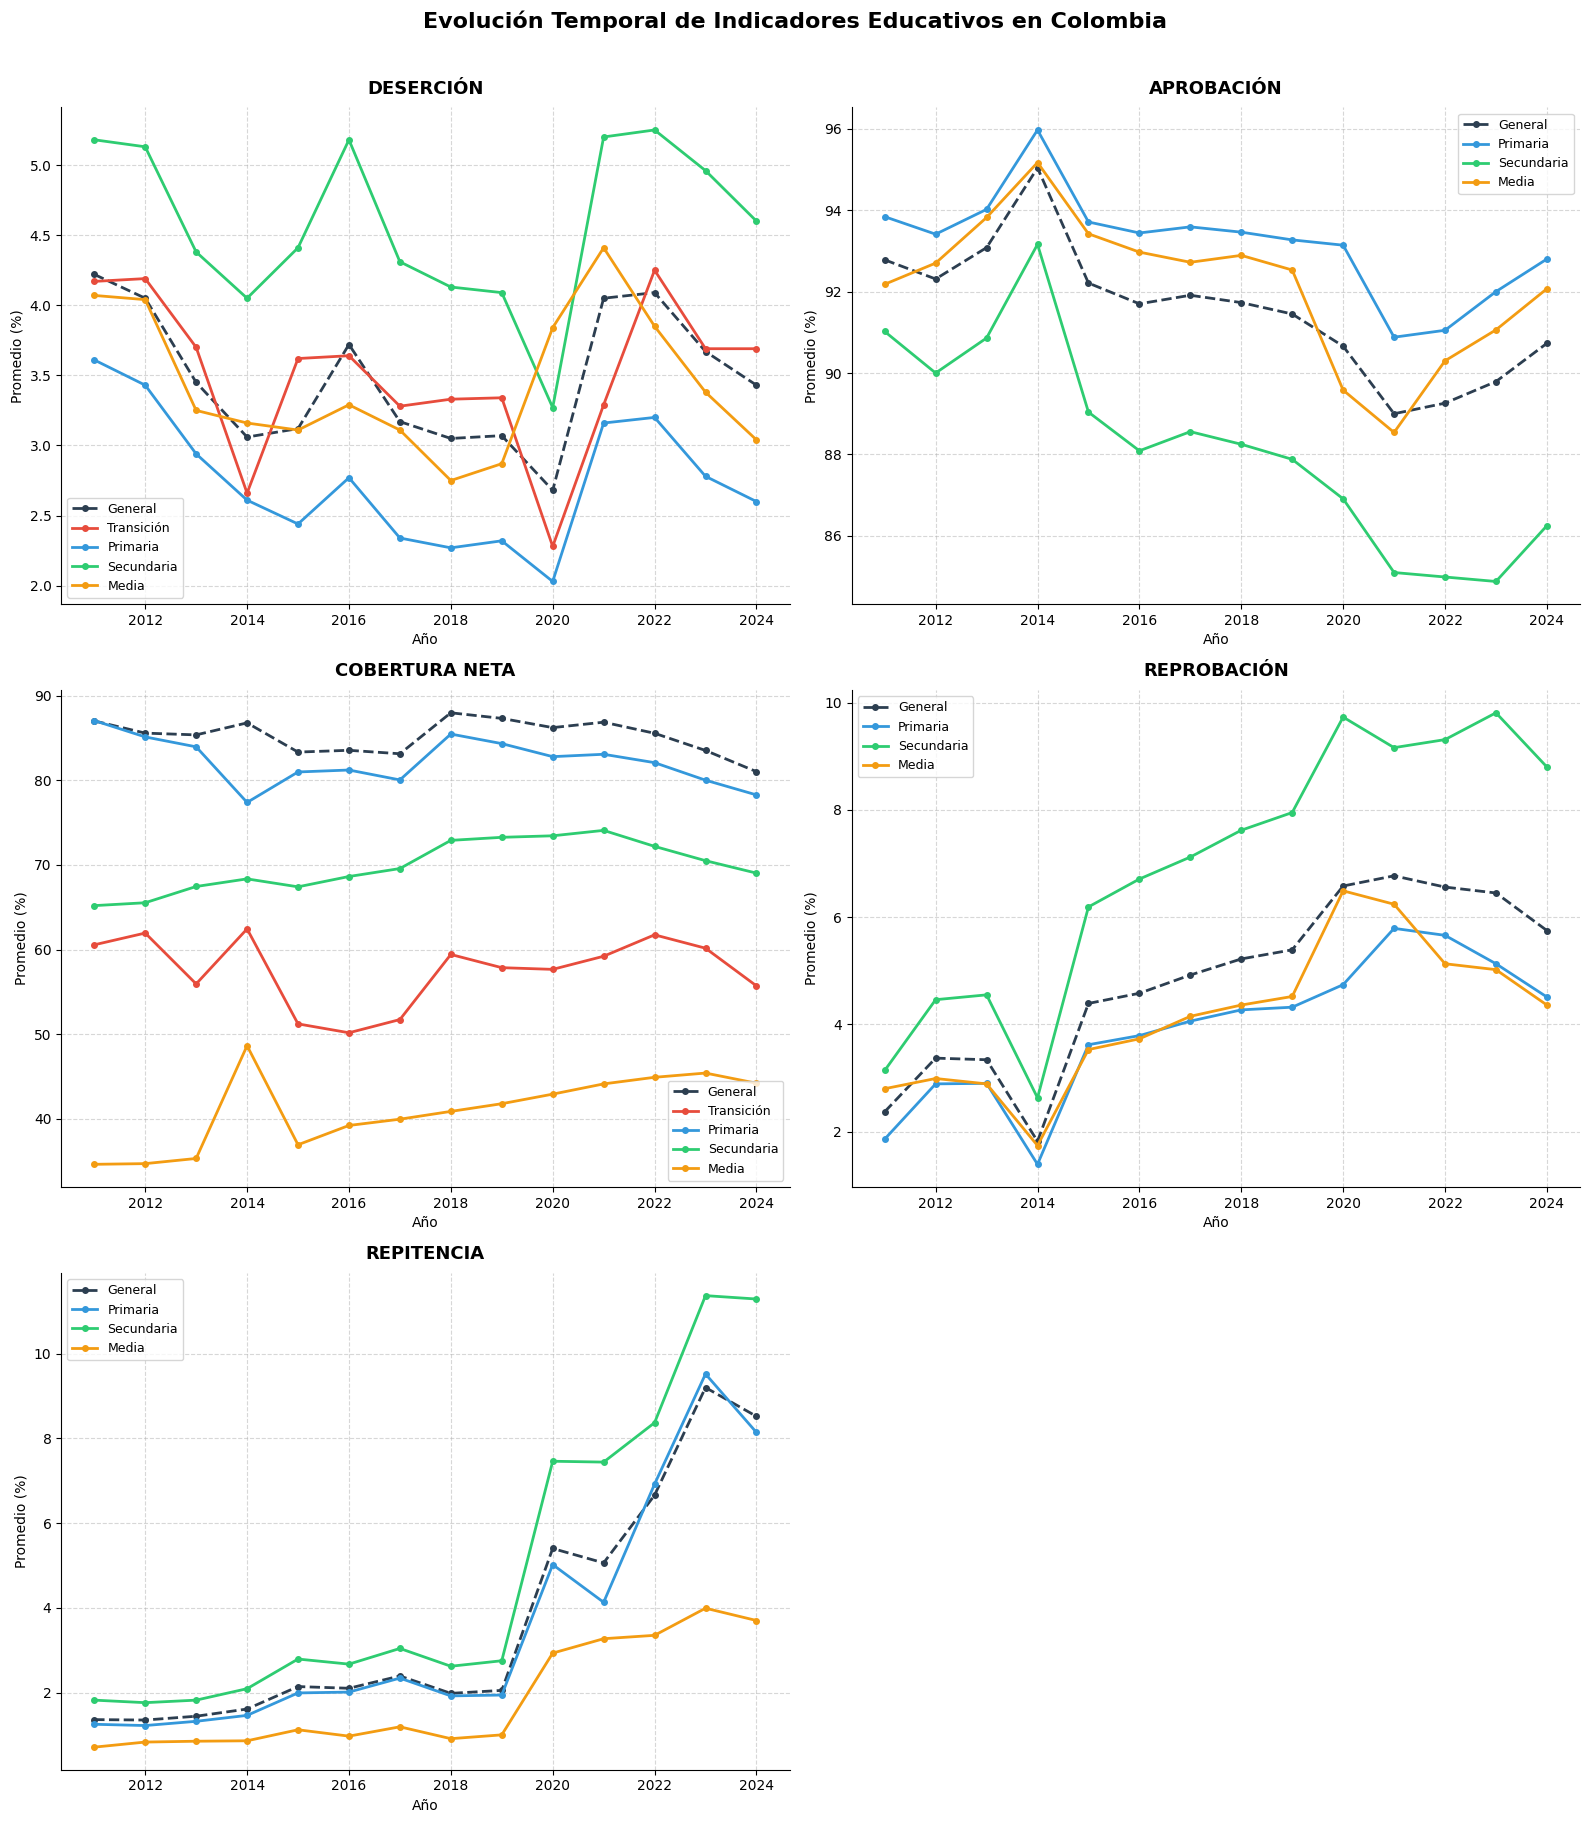

In [19]:
#### Analisis temporal de los indicadores del pais
# Agrupacion de indicadores
indicadores = {
    "DESERCIÓN": [
        "DESERCIÓN", "DESERCIÓN_TRANSICIÓN", "DESERCIÓN_PRIMARIA",
        "DESERCIÓN_SECUNDARIA", "DESERCIÓN_MEDIA"
    ],
    "APROBACIÓN": [
        "APROBACIÓN", "APROBACIÓN_PRIMARIA",
        "APROBACIÓN_SECUNDARIA", "APROBACIÓN_MEDIA"
    ],
    "COBERTURA NETA": [
        "COBERTURA_NETA", "COBERTURA_NETA_TRANSICIÓN", "COBERTURA_NETA_PRIMARIA",
        "COBERTURA_NETA_SECUNDARIA", "COBERTURA_NETA_MEDIA"
    ],
    "REPROBACIÓN": [
        "REPROBACIÓN", "REPROBACIÓN_PRIMARIA",
        "REPROBACIÓN_SECUNDARIA", "REPROBACIÓN_MEDIA"
    ],
    "REPITENCIA": [
        "REPITENCIA", "REPITENCIA_PRIMARIA",
        "REPITENCIA_SECUNDARIA", "REPITENCIA_MEDIA"
    ],
}

# Todas las columnas necesarias para la agregación
todas_columnas = [col for cols in indicadores.values() for col in cols]

# Creacion de base para visualizacion temporal
df_temporal = (
    dfPy01.groupBy("AÑO")
    .agg(*[F.round(F.mean(F.col(c)), 2).alias(c) for c in todas_columnas])
    .orderBy("AÑO")
    .toPandas()
)

# Creación de etiquetas para las leyendas
etiquetas = {
    # Deserción
    "DESERCIÓN":               "General",
    "DESERCIÓN_TRANSICIÓN":    "Transición",
    "DESERCIÓN_PRIMARIA":      "Primaria",
    "DESERCIÓN_SECUNDARIA":    "Secundaria",
    "DESERCIÓN_MEDIA":         "Media",
    # Aprobación
    "APROBACIÓN":              "General",
    "APROBACIÓN_TRANSICIÓN":   "Transición",
    "APROBACIÓN_PRIMARIA":     "Primaria",
    "APROBACIÓN_SECUNDARIA":   "Secundaria",
    "APROBACIÓN_MEDIA":        "Media",
    # Cobertura Neta
    "COBERTURA_NETA":                "General",
    "COBERTURA_NETA_TRANSICIÓN":     "Transición",
    "COBERTURA_NETA_PRIMARIA":       "Primaria",
    "COBERTURA_NETA_SECUNDARIA":     "Secundaria",
    "COBERTURA_NETA_MEDIA":          "Media",
    # Reprobación
    "REPROBACIÓN":             "General",
    "REPROBACIÓN_TRANSICIÓN":  "Transición",
    "REPROBACIÓN_PRIMARIA":    "Primaria",
    "REPROBACIÓN_SECUNDARIA":  "Secundaria",
    "REPROBACIÓN_MEDIA":       "Media",
    # Repitencia
    "REPITENCIA":              "General",
    "REPITENCIA_TRANSICIÓN":   "Transición",
    "REPITENCIA_PRIMARIA":     "Primaria",
    "REPITENCIA_SECUNDARIA":   "Secundaria",
    "REPITENCIA_MEDIA":        "Media",
}

colores = {
    "General":    "#2C3E50",
    "Transición": "#E74C3C",
    "Primaria":   "#3498DB",
    "Secundaria": "#2ECC71",
    "Media":      "#F39C12",
}

# Se grafica
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
fig.suptitle(
    "Evolución Temporal de Indicadores Educativos en Colombia",
    fontsize=16, fontweight="bold", y=1.01
)

# Aplanar y eliminar el subplot sobrante (3x2 = 6, tenemos 5 grupos)
axes_flat = axes.flatten()
axes_flat[-1].set_visible(False)

for ax, (nombre_grupo, columnas) in zip(axes_flat, indicadores.items()):
    for col in columnas:
        etiqueta = etiquetas[col]
        ax.plot(
            df_temporal["AÑO"],
            df_temporal[col],
            marker="o",
            linewidth=2,
            markersize=4,
            label=etiqueta,
            color=colores[etiqueta],
            linestyle="--" if etiqueta == "General" else "-",
        )

    ax.set_title(nombre_grupo, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Año", fontsize=10)
    ax.set_ylabel("Promedio (%)", fontsize=10)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Al realizar el análisis temporal de los indicadores del país, se ve que:
1. Secundaria muestra tasas de deserción superiores a los demás niveles educativos en todos los años
2. Se ve un aumento general en las tasas de deserción en todos los niveles después de la pandemia
3. Se ve una reducción general de aprobación en todos los niveles después de la pandemia
4. La cobertura neta ha disminuido en general dentro de la nación, donde la única en aumentar en los últimos 5 años fue la media.
5. Las tasas de reprobación han estado en aumento constante desde el 2014, hasta el 2021, donde empezaron a disminuir
6. Las tasas de repitencia han aumentado en gran medida desde el 2019
7. 2014 como el año con mejores índices generales de la nación
8. En general, se visualiza un empeoramiento en los indicadores de calidad del sistema de educación colombiano a lo largo de los años analizados, lo que indica falencias en las políticas impuestas sobre la educación en Colombia que han empeorado el sistema educativo durante todos estos años. Aunque también es de recalcar que se ven estabilizaciones o mejorías desde el 2021, indicando que este fue un año de cambio en la política Colombiana, donde se hizo más énfasis en mejorar la calidad educativa del país.

## **Reporte de calidad**

In [21]:
# Mostrar porcentaje de nulos por columna
from functools import reduce
# Cantidad de filas
total_filas = dfPy01.count()

nulos = dfPy01.select(
    *[
        F.round(
            (F.sum(F.col(c).isNull().cast("int")) / total_filas) * 100, 2
        ).alias(c)
        for c in columnas_numericas
    ]
)

# Transponer para mejor legibilidad
nulos_rows = []
for col in columnas_numericas:
    nulos_rows.append(
        nulos.select(
            F.lit(col).alias("Variable"),
            F.col(col).alias("% Nulos"),
        )
    )

df_nulos = reduce(lambda a, b: a.union(b), nulos_rows)
df_nulos.filter(F.col("% Nulos") > 0).orderBy(
    F.col("% Nulos").desc()
).show(truncate=False)

Total de filas en el dataset: 15707
+---------------------------+-------+
|Variable                   |% Nulos|
+---------------------------+-------+
|TAMAÑO_PROMEDIO_DE_GRUPO   |51.79  |
|SEDES_CONECTADAS_A_INTERNET|50.54  |
|DESERCIÓN_TRANSICIÓN       |5.75   |
|DESERCIÓN_MEDIA            |4.67   |
|DESERCIÓN_SECUNDARIA       |1.72   |
|DESERCIÓN_PRIMARIA         |1.54   |
|REPITENCIA_TRANSICIÓN      |1.01   |
|REPITENCIA_SECUNDARIA      |0.97   |
|REPITENCIA_PRIMARIA        |0.94   |
|REPROBACIÓN_MEDIA          |0.92   |
|REPITENCIA                 |0.91   |
|DESERCIÓN                  |0.9    |
|REPITENCIA_MEDIA           |0.88   |
|COBERTURA_BRUTA_MEDIA      |0.81   |
|TASA_MATRICULACIÓN_5_16    |0.73   |
|COBERTURA_NETA             |0.71   |
|REPROBACIÓN_SECUNDARIA     |0.67   |
|APROBACIÓN_MEDIA           |0.64   |
|REPROBACIÓN_PRIMARIA       |0.62   |
|COBERTURA_BRUTA_TRANSICIÓN |0.62   |
+---------------------------+-------+
only showing top 20 rows



In [24]:
# Columnas a revisar (excluyendo las dos con ~50% de nulos)
columnas_revisar = [c for c in dfPy01.columns if c not in [
    "TAMAÑO_PROMEDIO_DE_GRUPO",
    "SEDES_CONECTADAS_A_INTERNET"
]]

# Contar cantidad de filas con al menos un nulo
filas_con_nulo = dfPy01.filter(
    F.greatest(*[F.col(c).isNull().cast("int") for c in columnas_revisar]) == 1
).count()

print("=" * 50)
print(f"  Total de filas:               {total_filas:,}")
print(f"  Filas con al menos un nulo:   {filas_con_nulo:,}")
print(f"  Porcentaje:                   {filas_con_nulo / total_filas * 100:.2f}%")
print("=" * 50)

  Total de filas:               15,707
  Filas con al menos un nulo:   1,918
  Porcentaje:                   12.21%


In [29]:
## Para contar cuantas filas tienen x cantidad de variables nulas
# Contar cuántos nulos tiene cada fila
df_conteo_nulos = dfPy01.withColumn(
    "cantidad_nulos",
    sum([F.col(c).isNull().cast("int") for c in columnas_revisar])
)

# Ventana acumulada ordenada por cantidad de nulos
ventana_acumulada = Window.orderBy("cantidad_nulos").rowsBetween(
    Window.unboundedPreceding, Window.currentRow
)

# Agrupar y calcular porcentaje simple y acumulado
df_distribucion = (
    df_conteo_nulos
    .groupBy("cantidad_nulos")
    .count()
    .orderBy("cantidad_nulos")
    .withColumnRenamed("count", "cantidad_filas")
    .withColumn(
        "porcentaje",
        F.round(F.col("cantidad_filas") / total_filas * 100, 2)
    )
    .withColumn(
        "porcentaje_acumulado",
        F.round(F.sum("cantidad_filas").over(ventana_acumulada) / total_filas * 100, 2)
    )
)

df_distribucion.show(truncate=False)

+--------------+--------------+----------+--------------------+
|cantidad_nulos|cantidad_filas|porcentaje|porcentaje_acumulado|
+--------------+--------------+----------+--------------------+
|0             |13789         |87.79     |87.79               |
|1             |1010          |6.43      |94.22               |
|2             |378           |2.41      |96.63               |
|3             |223           |1.42      |98.05               |
|4             |105           |0.67      |98.71               |
|5             |70            |0.45      |99.16               |
|6             |35            |0.22      |99.38               |
|7             |7             |0.04      |99.43               |
|8             |21            |0.13      |99.56               |
|9             |10            |0.06      |99.62               |
|10            |4             |0.03      |99.65               |
|11            |11            |0.07      |99.72               |
|12            |5             |0.03     

Dado que las variables TAMAÑO_PROMEDIO_DE_GRUPO y SEDES_CONECTADAS_A_INTERNET tienen más de un 50% de los datos como nulos, se eliminará estas columnas del análisis, pues al tener una proporción tan grande de valores faltantes, sesgaran el modelo en gran medida y simplemente no hay suficientes datos para explicarlos.

Mientras que para el resto de valores, se ve que existen registros con la mayoría de variables en nulos, esto indica periodos en municipios que hubo fallos en el registro de los índices, dado que en estos casos faltarían más de la mitad de los registros, realizar imputación de los datos añadiría mucho sesgo en los resultados de esos periodos, por lo que se decide eliminar aquellas filas con 10 o más valores faltantes.

Mientras que para el resto de valores faltantes, se va a realizar una imputación 

In [ ]:
# Mostrar aquellos municipios con valores nulos
# Filtramos filas donde la incidencia O la mortalidad sean nulas
municipios_con_nulos = dfPy01.filter(
    F.col("tasa_incidencia").isNull() | 
    F.isnan(F.col("tasa_incidencia")) |
    F.col("tasa_mortalidad").isNull() | 
    F.isnan(F.col("tasa_mortalidad"))
)

print(f"Total de municipios con datos faltantes: {municipios_con_nulos.count()}")
municipios_con_nulos.select("municipio", "tasa_incidencia", "tasa_mortalidad").show()

In [ ]:
print(f"Cantidad de municipios en el dataset: {dfPy01.count()}")

Se reportan dos municipios con datos nulos dentro de todo el dataset. Se evidencia que ninguno de estos dos municipios cuenta ni con tasas de incidencia ni con tasas de mortalidad, por este motivo no tenemos ningún tipo de información extra que nos pueda guiar a los valores reales de estos datos. Dado esto, y el hecho de que son solamente 2 municipios de los 1122, los cuales representan solo el 0.18% de los datos totales. Se decide eliminarlos para el análisis.

## **Planteamiento de preguntas investigativas**

1. ¿Es afectado el rendimiento en las pruebas ICFES por factores de riego de salud como pandemias y enfermedades?
2. ¿Pueden llegar a afectar altas tasas de mortalidad y/o incidencia de enfermedades como el COVID-19 por municipio, en el rendimiento de la población estudiantil de esa zona?

## **Limpieza, filtro y transformaciones iniciales**

In [ ]:
# Limpieza de valores faltantes
# Solo elimina la fila si falta la incidencia O la mortalidad
dfPy02 = dfPy01.dropna(subset=["tasa_incidencia", "tasa_mortalidad"])

In [ ]:
# Conteo de cantidad de municipios
print(f"Cantidad de municipios previo a la eliminación: {dfPy01.count()}")
print(f"Cantidad de municipios post a la eliminación: {dfPy02.count()}")

Dado los resultados obtenidos en el análisis exploratorio, se va a normalizar las tasas aplicándoles una transformación logarítmica y filtrando aquellos atípicos mencionados en el análisis y se guardara este nuevo conjunto de datos aparte, se realizara este paso, ya que en caso de ser necesario aplicar modelos con supuestos de normalidad, se esperaría un mejor resultado predictivo por medio de estos datos normalizados sobre los datos base. Aunque se mantendrá aún los datos base en caso de aplicar técnicas sin supuestos de normalidad o ser necesario dar mayor explicación a los modelos.

In [ ]:
# Filtramos: eliminamos nulos y valores que sean 0 en cualquiera de las dos tasas
df_positivos = dfPy01.filter(
    (F.col("tasa_incidencia") > 0) & 
    (F.col("tasa_mortalidad") > 0)
)

# Aplicamos la transformación logarítmica (Logaritmo Natural)
# Creamos nuevas columnas para no sobreescribir las originales
df_log = df_positivos.withColumn("log_incidencia", F.log("tasa_incidencia")) \
                     .withColumn("log_mortalidad", F.log("tasa_mortalidad"))
# Verificamos cuántos datos quedaron después del filtro
conteo_original = dfPy01.count()
conteo_final = df_log.count()

print(f"Filas originales: {conteo_original}")
print(f"Filas tras eliminar ceros y nulos: {conteo_final}")
print(f"Municipios descartados: {conteo_original - conteo_final}")

# 4. Mostramos una muestra del resultado
df_log.select("municipio", "tasa_incidencia", "log_incidencia", "tasa_mortalidad", "log_mortalidad").show(5)

# 5. Convertimos a Pandas para gráficas Q-Q
pdf_log = df_log.select("log_incidencia", "log_mortalidad").toPandas()

In [ ]:
#Graficación de QQ plot filtrado y transformado
#Configurar la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Q-Q Plot Incidencia ---
stats.probplot(pdf_log["log_incidencia"], dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot: Log(Tasa de Incidencia)')
ax1.get_lines()[0].set_markerfacecolor('skyblue') # Color de los puntos
ax1.get_lines()[0].set_alpha(0.5)

# --- Q-Q Plot Mortalidad ---
stats.probplot(pdf_log["log_mortalidad"], dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot: Log(Tasa de Mortalidad)')
ax2.get_lines()[0].set_markerfacecolor('salmon') # Color de los puntos
ax2.get_lines()[0].set_alpha(0.5)

plt.tight_layout()
plt.show()

Los gráficos QQ plot indican datos normalizados más suaves que los originales, y aunque no están perfectamente alineados, se ve una gran mejoría de normalidad que sobre los datos base. Lo que en modelos con supuestos de normalidad, estabilizaría en mayor cantidad las predicciones hechas, y por consiguiente, la calidad de las mismas.